# EDA — Movies_and_TV.jsonl
AffDrift 프로젝트용 탐색적 데이터 분석 및 전처리

In [4]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.2f}'.format)

_HARDCODED_ROOT = Path("/home/seohyeon/.00_project/Recsys_02_AffDrift")

def find_project_root(start: Path | None = None) -> Path:
    """Find the AffDrift project root from the current working directory."""
    env_root = os.getenv("AFFDRIFT_PROJECT_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data/raw/Movies_and_TV.jsonl").exists():
            return candidate

    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data/raw/Movies_and_TV.jsonl").exists():
            return candidate

    # 하드코딩된 fallback (PyCharm 등 IDE가 /tmp를 cwd로 잡을 때)
    if (_HARDCODED_ROOT / "data/raw/Movies_and_TV.jsonl").exists():
        return _HARDCODED_ROOT

    raise FileNotFoundError(
        "Could not find the AffDrift project root. "
        f"cwd={current}, set AFFDRIFT_PROJECT_ROOT if needed."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Movies_and_TV.jsonl"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: /home/seohyeon/.00_project/Recsys_02_AffDrift


## 1. 데이터 로드
약 1700만 줄 — 메모리 4~6GB 예상

In [5]:
records = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"총 리뷰 수: {len(df):,}")
print(f"컬럼: {df.columns.tolist()}")
df.head(3)

총 리뷰 수: 17,328,314
컬럼: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.00,Five Stars,"Amazon, please buy the show! I'm hooked!",[],B013488XFS,B013488XFS,AGGZ357AO26RQZVRLGU4D4N52DZQ,1440385637000,0,True
1,5.00,Five Stars,My Kiddos LOVE this show!!,[],B00CB6VTDS,B00CB6VTDS,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1461100610000,0,True
2,3.00,Some decent moments...but...,Annabella Sciorra did her character justice wi...,[],B096Z8Z3R6,B096Z8Z3R6,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1646271834582,0,True


## 2. 기본 통계

In [6]:
n_users = df['user_id'].nunique()
n_items = df['parent_asin'].nunique()

print(f"유저 수   : {n_users:,}")
print(f"아이템 수 : {n_items:,}")
print(f"평균 평점 : {df['rating'].mean():.3f}")
print(f"\n결측치:\n{df.isnull().sum()}")
print(f"\n평점 분포:\n{df['rating'].value_counts().sort_index()}")

유저 수   : 6,503,429
아이템 수 : 747,764
평균 평점 : 4.246

결측치:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

평점 분포:
rating
1.00     1410250
2.00      766735
3.00     1260217
4.00     2604827
5.00    11286285
Name: count, dtype: int64


## 3. Timestamp → Datetime 변환

In [7]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.to_period('M')

print(f"기간: {df['datetime'].min()} ~ {df['datetime'].max()}")
df['year'].value_counts().sort_index()

기간: 1997-08-24 02:46:15 ~ 2023-09-12 22:13:12.711000


year
1997         33
1998       1479
1999      15505
2000      51264
2001      52598
2002      58341
2003      60734
2004      81785
2005     106033
2006     110988
2007     151495
2008     147867
2009     160908
2010     173260
2011     203753
2012     378100
2013    1198595
2014    2043793
2015    2802738
2016    3558166
2017    1535239
2018     995809
2019    1028925
2020     777173
2021     803211
2022     624152
2023     206370
Name: count, dtype: int64

## 4. 평점 분포 & 연도별 리뷰 수 시각화

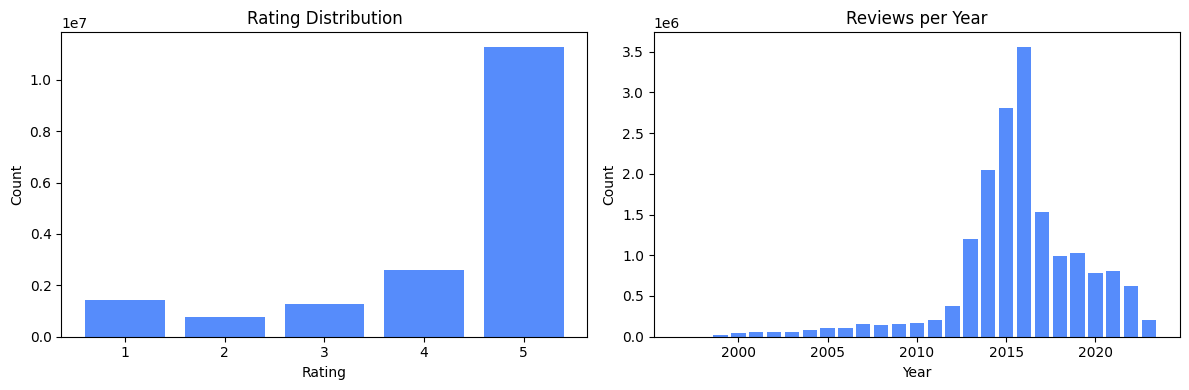

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

year_counts = df['year'].value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values)
axes[1].set_title("Reviews per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. 유저별 리뷰 수 분포 (시퀀셜 추천 핵심)

In [9]:
user_counts = df.groupby('user_id').size()

print(f"유저당 평균 리뷰 수: {user_counts.mean():.2f}")
print(f"중앙값             : {user_counts.median():.0f}")
print(f"최대               : {user_counts.max()}")
print(f"\n리뷰 수 구간별 유저 비율:")

bins = [1, 2, 5, 10, 20, 50, 100, int(user_counts.max()) + 1]
labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100+']
cut = pd.cut(user_counts, bins=bins, labels=labels, right=False)
print(cut.value_counts().sort_index())

유저당 평균 리뷰 수: 2.66
중앙값             : 1
최대               : 4369

리뷰 수 구간별 유저 비율:
1        3806145
2-4      1970998
5-9       482326
10-19     168094
20-49      61192
50-99      10712
100+        3962
Name: count, dtype: int64


## 6. 아이템별 리뷰 수 분포

아이템당 평균 리뷰 수: 23.17
중앙값               : 3
최대                 : 62445


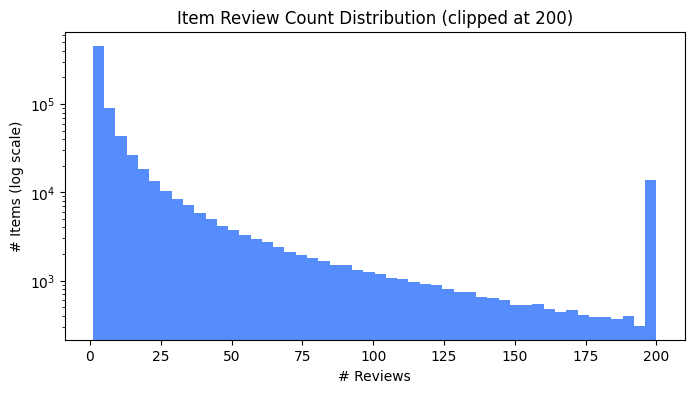

In [10]:
item_counts = df.groupby('parent_asin').size()

print(f"아이템당 평균 리뷰 수: {item_counts.mean():.2f}")
print(f"중앙값               : {item_counts.median():.0f}")
print(f"최대                 : {item_counts.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(item_counts.clip(upper=200), bins=50, log=True)
ax.set_title("Item Review Count Distribution (clipped at 200)")
ax.set_xlabel("# Reviews")
ax.set_ylabel("# Items (log scale)")
plt.show()

## 7. K-core 필터링 (표준 전처리)

In [11]:
K = 5

def kcore_filter(df, k, user_col='user_id', item_col='parent_asin'):
    while True:
        user_mask = df[user_col].map(df[user_col].value_counts()) >= k
        item_mask = df[item_col].map(df[item_col].value_counts()) >= k
        df_new = df[user_mask & item_mask]
        if len(df_new) == len(df):
            break
        df = df_new
    return df

df_filtered = kcore_filter(df, K)

print(f"필터 전: {len(df):,} reviews / {df['user_id'].nunique():,} users / {df['parent_asin'].nunique():,} items")
print(f"필터 후: {len(df_filtered):,} reviews / {df_filtered['user_id'].nunique():,} users / {df_filtered['parent_asin'].nunique():,} items")
print(f"유지율 : {len(df_filtered)/len(df)*100:.1f}%")

필터 전: 17,328,314 reviews / 6,503,429 users / 747,764 items
필터 후: 7,569,068 reviews / 666,889 users / 200,151 items
유지율 : 43.7%


## 8. 시간순 정렬 확인 (Drift 분석용)

In [12]:
sample_users = df_filtered['user_id'].value_counts().head(5).index

for uid in sample_users:
    user_df = df_filtered[df_filtered['user_id'] == uid].sort_values('timestamp')
    ratings = user_df['rating'].tolist()
    print(f"user {uid[:12]}... ({len(ratings)} reviews): {ratings}")

user AGVYDLC4T7LO... (3083 reviews): [4.0, 3.0, 2.0, 2.0, 3.0, 2.0, 2.0, 5.0, 3.0, 4.0, 4.0, 4.0, 5.0, 5.0, 4.0, 5.0, 4.0, 4.0, 5.0, 4.0, 2.0, 1.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 4.0, 2.0, 5.0, 4.0, 4.0, 3.0, 4.0, 1.0, 4.0, 4.0, 4.0, 4.0, 4.0, 2.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 2.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 3.0, 5.0, 5.0, 4.0, 5.0, 4.0, 2.0, 5.0, 4.0, 4.0, 2.0, 4.0, 4.0, 4.0, 5.0, 4.0, 5.0, 4.0, 4.0, 3.0, 1.0, 1.0, 2.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 5.0, 3.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 2.0, 4.0, 3.0, 4.0, 4.0, 4.0, 2.0, 2.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 5.0, 4.0, 4.0, 4.0, 2.0, 3.0, 3.0, 3.0, 4.0, 4.0, 5.0, 4.0, 3.0, 2.0, 5.0, 5.0, 3.0, 2.0, 4.0, 4.0, 5.0, 4.0, 5.0, 4.0, 5.0, 4.0, 2.0, 4.0, 5.0, 2.0, 1.0, 1.0, 2.0, 5.

## 9. 텍스트 길이 분포

평균 텍스트 길이: 291.6 chars
중앙값          : 102 chars
빈 텍스트 비율  : 0.00%


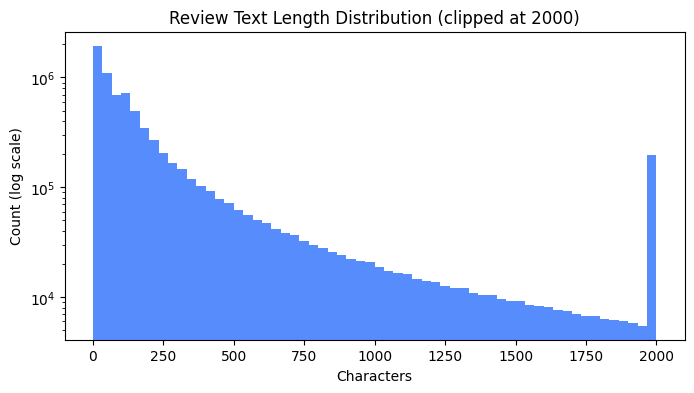

In [13]:
df_filtered['text_len'] = df_filtered['text'].fillna('').apply(len)

print(f"평균 텍스트 길이: {df_filtered['text_len'].mean():.1f} chars")
print(f"중앙값          : {df_filtered['text_len'].median():.0f} chars")
print(f"빈 텍스트 비율  : {(df_filtered['text_len'] == 0).mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_filtered['text_len'].clip(upper=2000), b> ins=60, log=True)
ax.set_title("Review Text Length Distribution (clipped at 2000)")
ax.set_xlabel("Characters")
ax.set_ylabel("Count (log scale)")
plt.show()


In [14]:
# 같은 유저-아이템 쌍이 2회 이상인 케이스 집계
pair_counts = (
    df.groupby(["user_id", "parent_asin"])
      .size()
      .rename("n_reviews")
      .reset_index()
)

multi = pair_counts[pair_counts["n_reviews"] >= 2]

print(f"전체 (user,item) 쌍: {len(pair_counts):,}")
print(f"2회 이상 리뷰한 (user,item) 쌍: {len(multi):,}")
print(f"비율: {len(multi) / len(pair_counts) * 100:.4f}%")
print(f"초과 리뷰 수(중복분): {(multi['n_reviews'] - 1).sum():,}")

# 참고: 유저 기준으로도 확인
users_with_repeat = multi["user_id"].nunique()
print(f"같은 아이템 재리뷰 경험 유저 수: {users_with_repeat:,}")

전체 (user,item) 쌍: 17,158,519
2회 이상 리뷰한 (user,item) 쌍: 147,162
비율: 0.8577%
초과 리뷰 수(중복분): 169,795
같은 아이템 재리뷰 경험 유저 수: 68,445


In [15]:
## 10. 텍스트 예시 확인

def _short(text, n=160):
    text = (text or "").replace("\n", " ").strip()
    return text[:n] + ("..." if len(text) > n else "")


# 1) 같은 유저-같은 아이템에 여러 번 리뷰한 케이스 예시
print("=== [A] 반복 리뷰(user_id, parent_asin 동일) 예시 ===")
dup_pairs = (
    df.groupby(["user_id", "parent_asin"])
    .size()
    .reset_index(name="n_reviews")
    .query("n_reviews >= 2")
    .sort_values("n_reviews", ascending=False)
)

if len(dup_pairs) == 0:
    print("반복 리뷰 케이스가 없습니다.")
else:
    # 상위 3개 페어만 예시
    for i, row in dup_pairs.head(3).iterrows():
        uid = row["user_id"]
        asin = row["parent_asin"]
        n_reviews = int(row["n_reviews"])

        sub = (
            df[(df["user_id"] == uid) & (df["parent_asin"] == asin)]
            .sort_values("timestamp")
            .copy()
        )
        sub["dt"] = pd.to_datetime(sub["timestamp"], unit="ms", errors="coerce")
        sub["text_len"] = sub["text"].fillna("").str.len()

        print(f"\n[Pair] user={uid[:12]}..., item={asin}, n_reviews={n_reviews}")
        for j, r in sub.iterrows():
            print(
                f"- {r['dt']} | rating={r.get('rating', None)} | len={r['text_len']}\n"
                f"  text: {_short(r.get('text', ''), 180)}"
            )

# 2) 전체 데이터에서 랜덤 텍스트 예시
print("\n=== [B] 전체 랜덤 리뷰 예시 ===")
sample_n = 5
rand = df.sample(n=min(sample_n, len(df)), random_state=42).copy()
rand["dt"] = pd.to_datetime(rand["timestamp"], unit="ms", errors="coerce")
rand["text_len"] = rand["text"].fillna("").str.len()

for _, r in rand.iterrows():
    print(
        f"- user={r['user_id'][:12]}..., item={r['parent_asin']}, "
        f"time={r['dt']}, rating={r.get('rating', None)}, len={r['text_len']}\n"
        f"  text: {_short(r.get('text', ''), 180)}"
    )

=== [A] 반복 리뷰(user_id, parent_asin 동일) 예시 ===

[Pair] user=AG4GHJ6TMSZU..., item=B00JZHPUUE, n_reviews=11
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob
- 2015-02-20 18:34:45 | rating=5.0 | len=9
  text: Great iob

[Pair] user=AG4GHJ6TMSZU..., item=B00JZHPICY, n_reviews=11
- 2016-01-19 23:29:36 | rating=5.0 | len=57
  text: Enjoyed watching it very much Enjoyed riding it even more
- 2016-01-19 23:29:36 | rating=5.0 | len=57
  text: E